<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.13}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Sita Zoe Sotomayor Carrillo \\[6pt]
\textbf{Fecha de realización:} & 03/03/2026
\end{array}

</center>

#PARTE 4: Problema de las 8 Reinas
Colocar 8 reinas en un tablero de ajedrez sin que se ataquen.

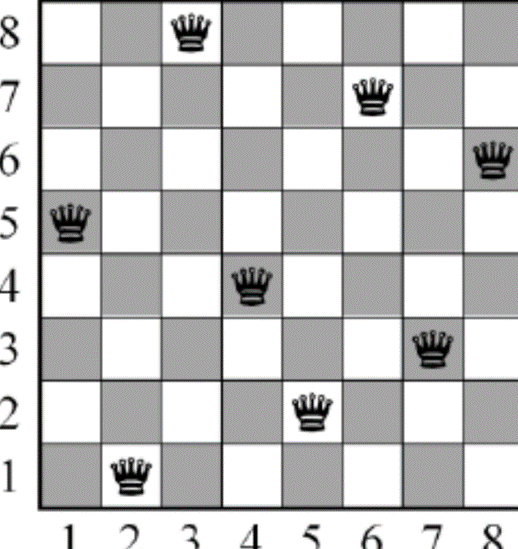

# **1. Definiciones del Problema**
Para explicar esto se puede desglosar así:

- **Estado**: Una lista o vector $L = [c_0, c_1, ..., c_7]$ donde cada índice representa una fila y el valor $c_i$ representa la columna donde está la reina. Un estado parcial tiene algunas reinas colocadas; un estado final tiene las 8 sin ataques.

- **Operadores**: Colocar una reina en la siguiente fila vacía ($fila + 1$) en una columna $j$ tal que $0 \leq j < 8$, siempre que no sea atacada por las reinas previas.

- **Función objetivo**: Verificar si hemos llegado a la fila 8 (todas las reinas colocadas) cumpliendo las restricciones de no ataque.Espacio de Búsqueda: Si no usáramos reglas, sería $8^8$ (16,777,216 estados). Si restringimos a una reina por columna y fila, baja a $8!$ (40,320 estados).

- **¿Es un problema de satisfacción de restricciones (CSP)?** Sí. Las variables son las posiciones de las reinas, el dominio son las casillas del tablero $\{0...7\}$ y las restricciones son que no pueden compartir fila, columna ni diagonal.

- **¿Cómo cambia si usamos A estrella?**  Pasamos de una búsqueda "ciega" (Backtracking/DFS) a una búsqueda informada. A* necesita un costo acumulado $g(n)$ (reinas colocadas) y una heurística $h(n)$. El algoritmo priorizaría expandir ramas que parezcan "más prometedoras".

- **¿Qué heurística podría aplicarse?** Una común es el Número de conflictos potenciales: Contar cuántas casillas quedan "libres" o seguras en las filas restantes. A más casillas libres, mejor es el estado.

# Programa

Solución encontrada:
Reina en fila 0 y columna 0
Reina en fila 1 y columna 4
Reina en fila 2 y columna 7
Reina en fila 3 y columna 5
Reina en fila 4 y columna 2
Reina en fila 5 y columna 6
Reina en fila 6 y columna 1
Reina en fila 7 y columna 3


<Figure size 800x800 with 0 Axes>

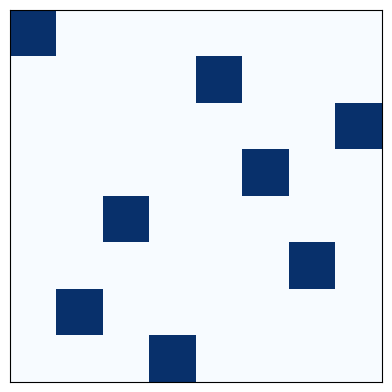

In [ ]:
import matplotlib.pyplot as plt

def es_seguro(tablero, fila, columna):
    # Verificar si es seguro colocar una reina en la fila, columna
    for i in range(fila):
        if tablero[i] == columna or \
           tablero[i] - i == columna - fila or \
           tablero[i] + i == columna + fila:
            return False
    return True

def resolver_8_reinas(tablero, fila):
    if fila == 8:
        return True
    for columna in range(8):
        if es_seguro(tablero, fila, columna):
            tablero[fila] = columna
            if resolver_8_reinas(tablero, fila + 1):
                return True
            tablero[fila] = -1
    return False

def dibujar_tablero(tablero):
    plt.figure(figsize=(8, 8))
    plt.matshow([[tablero[i] == j for j in range(8)] for i in range(8)], cmap="Blues")
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Inicializar el tablero
tablero = [-1] * 8

# Resolver el problema de las 8 reinas
if resolver_8_reinas(tablero, 0):
    print("Solución encontrada:")
    for fila, columna in enumerate(tablero):
        print(f"Reina en fila {fila} y columna {columna}")
    dibujar_tablero(tablero)
else:
    print("No se encontró solución.")

Preguntas:
1. ¿Es un algoritmo óptimo?
2. Indica la complejidad y espacio de búsqueda con el programa propuesto
3. Indica la limitación del código actual
4. Realiza una mejora sobre el programa y establece el pseudocodigo previo.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>

Codigo mejorado

Total de soluciones encontradas: 92
Mostrando las primeras 3:


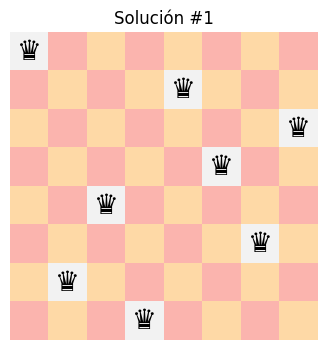

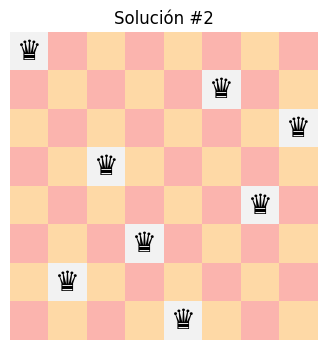

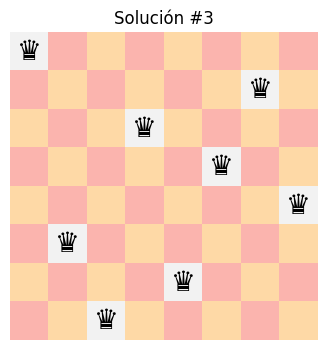

In [1]:
import matplotlib.pyplot as plt

def dibujar_tablero(tablero, indice_solucion):
    plt.figure(figsize=(4, 4))
    matriz = [[(i + j) % 2 == 0 for j in range(8)] for i in range(8)] # Tablero ajedrezado base

    # Superponemos las reinas
    for fila, col in enumerate(tablero):
        matriz[fila][col] = 2 # Valor especial para la reina

    plt.imshow(matriz, cmap="Pastel1") # Colores suaves
    # Dibujamos las 'Q'
    for fila, col in enumerate(tablero):
        plt.text(col, fila, '♛', ha='center', va='center', fontsize=20, color='black')

    plt.title(f"Solución #{indice_solucion}")
    plt.axis('off')
    plt.show()

# --- ALGORITMO MEJORADO (ENCUENTRA TODAS LAS SOLUCIONES) ---
def resolver_todas_8_reinas(tablero, fila, soluciones):
    if fila == 8:
        # ¡Solución encontrada! Guardamos una copia
        soluciones.append(list(tablero))
        return

    for col in range(8):
        # Chequeo de seguridad optimizado (sin función externa para velocidad)
        es_seguro = True
        for i in range(fila):
            # Misma columna o diagonal
            if tablero[i] == col or \
               abs(tablero[i] - col) == abs(i - fila):
                es_seguro = False
                break

        if es_seguro:
            tablero[fila] = col
            resolver_todas_8_reinas(tablero, fila + 1, soluciones)
            # No hay return True aquí, el loop sigue para buscar más opciones (Backtracking completo)
            tablero[fila] = -1

# --- EJECUCIÓN ---
tablero = [-1] * 8
todas_soluciones = []
resolver_todas_8_reinas(tablero, 0, todas_soluciones)

print(f"Total de soluciones encontradas: {len(todas_soluciones)}")
print("Mostrando las primeras 3:")
for i in range(3):
    dibujar_tablero(todas_soluciones[i], i+1)